# Model Comparison

### Import Libraries

In [12]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Load Custom CNN Results

In [13]:
# code

custom_results_path = "../results/result.csv"

custom_df = pd.read_csv(custom_results_path)

custom_df

,Unnamed: 0,bird,drone,accuracy,macro avg,weighted avg
0,precision,0.923077,0.839806,0.880299,0.881441,0.884037
1,recall,0.845070,0.920213,0.880299,0.882642,0.880299
2,f1-score,0.882353,0.878173,0.880299,0.880263,0.880393
3,support,213.000000,188.000000,0.880299,401.000000,401.000000


### Extract Custom CNN Metrics

In [14]:
# values

custom_accuracy = 0.910224

custom_precision = 0.912029

custom_recall = 0.910224

custom_f1 = 0.910312

### Load Transfer Learning Results

In [15]:
# code

transfer_results_path = "../results/transfer_learning_results.csv"

transfer_df = pd.read_csv(transfer_results_path)

transfer_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time (min),Model Size (MB)
0,ResNet50,0.710723,0.715865,0.710723,0.705920,66.821915,93.615857
1,MobileNet,0.982544,0.982550,0.982544,0.982541,23.679772,14.135868
2,EfficientNetB0,0.531172,0.282144,0.531172,0.368533,15.766228,18.136642


### Create Custom CNN Row

In [16]:
# code

custom_model_row = pd.DataFrame({

    "Model": ["Custom CNN"],

    "Accuracy": [custom_accuracy],

    "Precision": [custom_precision],

    "Recall": [custom_recall],

    "F1-score": [custom_f1],

    "Training Time (min)": [None],

    "Model Size (MB)": [None]

})

### Combine All Models

In [17]:
# code

comparison_df = pd.concat(

    [custom_model_row, transfer_df],

    ignore_index=True

)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time (min),Model Size (MB)
0,Custom CNN,0.910224,0.912029,0.910224,0.910312,None,None
1,ResNet50,0.710723,0.715865,0.710723,0.705920,66.821915,93.615857
2,MobileNet,0.982544,0.982550,0.982544,0.982541,23.679772,14.135868
3,EfficientNetB0,0.531172,0.282144,0.531172,0.368533,15.766228,18.136642


### Save Combined Results

In [18]:
# code

comparison_df.to_csv(

    "../results/model_comparison.csv",

    index=False

)

print("Model comparison saved.")

Model comparison saved.


### Handle the missing values

In [19]:
# code -> Fix missing numeric values

import pandas as pd

# Convert columns to numeric safely

comparison_df["Training Time (min)"] = pd.to_numeric(
    comparison_df["Training Time (min)"],
    errors="coerce"
)

comparison_df["Model Size (MB)"] = pd.to_numeric(
    comparison_df["Model Size (MB)"],
    errors="coerce"
)

# Replace NaN with 0

comparison_df["Training Time (min)"] = (
    comparison_df["Training Time (min)"]
    .fillna(0)
)

comparison_df["Model Size (MB)"] = (
    comparison_df["Model Size (MB)"]
    .fillna(0)
)

print("Data types after fix:")
print(comparison_df.dtypes)

Data types after fix:
Model                      str
Accuracy               float64
Precision              float64
Recall                 float64
F1-score               float64
Training Time (min)    float64
Model Size (MB)        float64
dtype: object


### Plot Accuracy Comparison

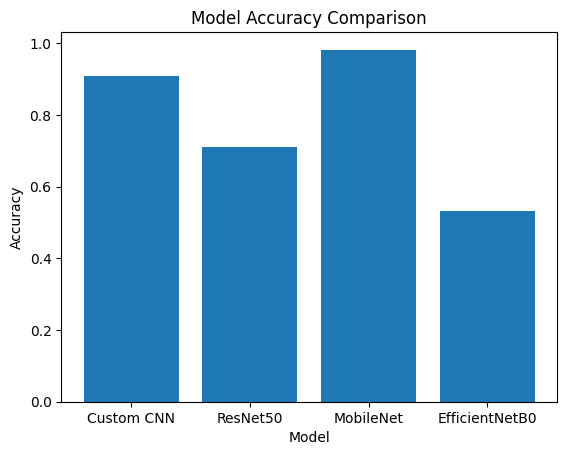

In [20]:
# code

plt.figure()

plt.bar(

    comparison_df["Model"],

    comparison_df["Accuracy"]

)

plt.title("Model Accuracy Comparison")

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.show()

### Plot F1-Score Comparison

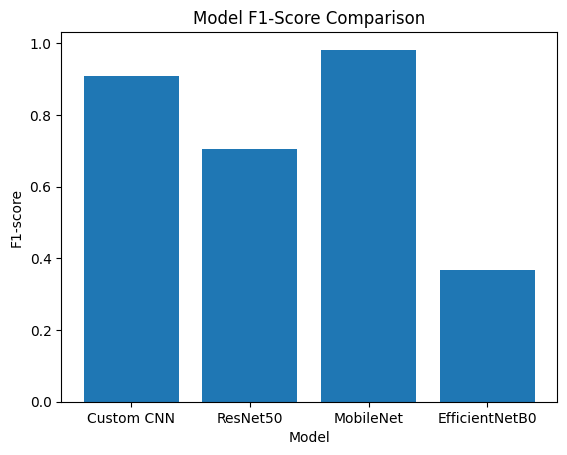

In [21]:
plt.figure()

plt.bar(

    comparison_df["Model"],

    comparison_df["F1-score"]

)

plt.title("Model F1-Score Comparison")

plt.xlabel("Model")

plt.ylabel("F1-score")

plt.show()

### Plot Training Time

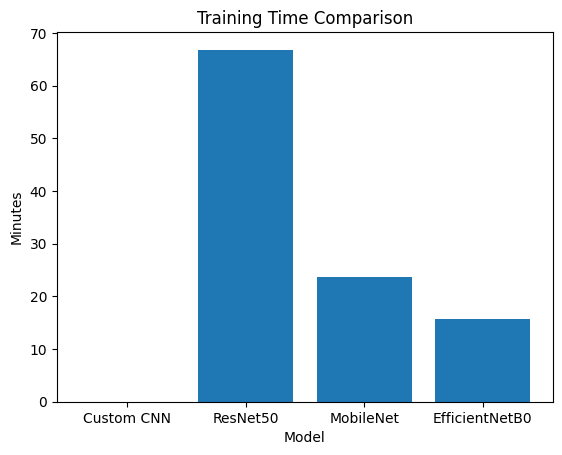

In [23]:
# code

plt.figure()

plt.bar(

    comparison_df["Model"],

    comparison_df["Training Time (min)"]

)

plt.title("Training Time Comparison")

plt.xlabel("Model")

plt.ylabel("Minutes")

plt.show()

### Plot Model Size

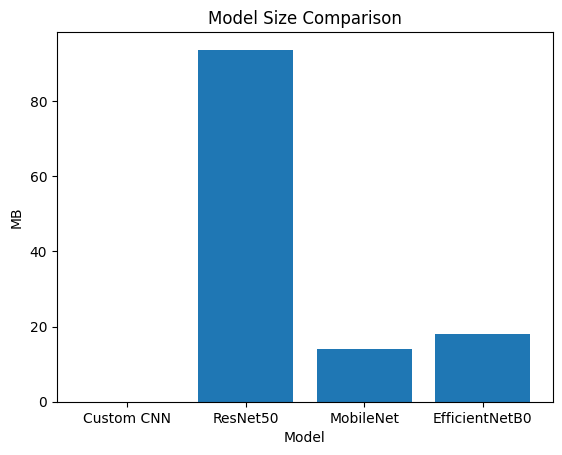

In [24]:
# code

plt.figure()

plt.bar(

    comparison_df["Model"],

    comparison_df["Model Size (MB)"]

)

plt.title("Model Size Comparison")

plt.xlabel("Model")

plt.ylabel("MB")

plt.show()

### Select Best Model Automatically

In [25]:
best_model = comparison_df.loc[

    comparison_df["F1-score"].idxmax()

]

best_model

Model                  MobileNet
Accuracy                0.982544
Precision                0.98255
Recall                  0.982544
F1-score                0.982541
Training Time (min)    23.679772
Model Size (MB)        14.135868
Name: 2, dtype: object

### Print Best Model

In [26]:
# code

print("Best Model Selected:")

print(best_model["Model"])

print("F1-score:", best_model["F1-score"])

Best Model Selected:
MobileNet
F1-score: 0.9825408064538108


### Save Best Model Info

In [27]:
# code

best_model.to_frame().T.to_csv(

    "../results/best_model.csv",

    index=False

)

print("Best model saved.")

Best model saved.
